<a href="https://colab.research.google.com/github/wellingtondmf/pos_puc_2026/blob/Colab/MVP_ML_Analytics_Wellington_rascunho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status | Como foi cumprido |
|---|---|---|
|Problema definido com contexto, objetivo e tipo de tarefa |✅| A Seção 1 do notebook descreve claramente o contexto médico (câncer), define o objetivo (segunda opinião automatizada) e crava o tipo da tarefa como Classificação Binária.|
|Dataset descrito, com fonte, atributos e restrições | ✅ | A Seção 3 e o Dicionário de Dados detalham a base Breast Cancer Wisconsin, a origem na UCI, as dimensões (569 linhas, 30 colunas) e a natureza anonimizada (restrições) dos dados.|
|Dataset carregado por URL pública ou fonte diretamente acessível | ✅ |O uso da função load_breast_cancer(as_frame=True) do scikit-learn garante que o notebook rode sem necessidade de upload de arquivos CSV locais ou chaves de API.|
|Análise exploratória objetiva, conectada à modelagem | ✅ |Os gráficos de boxplo validaram a Hipótese 1 (raio/perímetro maiores nos tumores malignos) e comprovam a necessidade visual de nivelar a escala dos dados.|
|Divisão adequada em treino/teste e, se aplicável, validação | ✅ |A função train_test_split aplicou o corte de 70/30 e o parâmetro stratify=y garantiu a proporção correta das classes. A validação cruzada (cv=5) foi aplicada na etapa de otimização.|
|Prevenção de vazamento de dados | ✅ |O transformador StandardScaler foi embutido dentro de um objeto Pipeline, garantindo que os dados de teste não influenciem o cálculo das médias e desvios-padrão do treino.|
|Tratamentos de dados justificados | ✅ |O escalonamento (padronização) foi justificado textualmente devido à diferença de grandeza das variáveis (áreas na casa dos milhares vs. suavidade em decimais).|
| Pipeline ou sequência reprodutível de pré-processamento | ✅ |A função treinar_modelo monta e aciona um sklearn.pipeline.Pipeline de forma dinâmica e automatizada.|
| Modelo baseline definido | ✅ |A Regressão Logística foi explicitamente estabelecida como a "régua" básica e interpretável do experimento.|
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✅ |Foram treinados o Baseline (Regressão Logística), um ensemble baseado em árvores (Random Forest) e um modelo de margem (SVM).
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✅ | O GridSearchCV explorou os parâmetros C e kernel do SVM, buscando maximizar a métrica de sensibilidade médica.|
| Avaliação com métricas coerentes com o problema | ✅ |O foco da avaliação foi direcionado para o Recall da classe maligna, justificando que, no domínio da saúde, falsos negativos são o erro mais crítico a ser evitado. Matriz de confusão e F1-Score apoiaram a análise.|
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |A seção de conclusões e os comentários analisam a natureza quase perfeitamente linear do dataset (explicando o empate técnico dos modelos) e apontam o tamanho reduzido da amostra (569) como uma limitação de generalização.|
| Código limpo, organizado e executável do início ao fim | ✅ |A refatoração modulariza o código em funções orquestradas, utiliza type hinting (tipagem) e garante reprodutibilidade via fixação de variáveis globais (SEED = 42).|
| Conclusão conectada ao objetivo inicial | ✅ |A conclusão retoma a premissa inicial de criar uma solução viável e demonstra técnica ao escolher o modelo Baseline como vencedor prático (por apresentar os mesmos resultados com menor custo e maior interpretabilidade).|

# MVP — Machine Learning & Analytics

**Nome:** _Wellington de Melo Freitas_  
**Matrícula:** _Sua matrícula aqui_  
**Data:** _dd/mm/aaaa_  
**Dataset:** _Breast Cancer Wisconsin (Carregado via sklearn.datasets.load_breast_cancer)_  
**Tipo de problema:** _Classificação_  

---

#1. Definição do problema
##1.1 - Descrição do problema
- O câncer é uma das principais causas de mortalidade no mundo. O diagnóstico precoce e preciso é fundamental para o sucesso do tratamento. Este projeto aborda o problema de classificar tumores como malignos ou benignos com base em características extraídas de imagens digitalizadas de biópsias (FNA - Fine Needle Aspirate).

- O modelo apoiará médicos em suas decisões, servindo como uma segunda opinião automatizada.
- O problema é tratado com Machine Learning porque os padrões visuais e métricos que diferenciam células malignas de benignas são complexos e ideais para algoritmos de reconhecimento de padrões supervisionados.

##1.2 Objetivo do MVP
- O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a malignidade de tumores a partir de características celulares, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.

##1.3 Tipo de problema
- Tipo escolhido: Classificação Binária.
- Justificativa: O objetivo central é alocar cada tumor em uma de duas categorias discretas e mutuamente exclusivas: Maligno (0) ou Benigno (1). Não buscamos prever um valor contínuo (regressão) nem encontrar grupos ocultos (clusterização).

## 1.4 Premissas, hipóteses e critérios de sucesso
**Hipóteses iniciais:**

- **Hipótese 1**: Células malignas apresentam maior variação de tamanho e forma (maior raio, perímetro e área média) em comparação com células benignas.

- **Hipótese 2**: Algoritmos não lineares (como Random Forest ou SVM com kernel RBF) apresentarão melhor desempenho que modelos lineares simples, devido à possível não-linearidade das fronteiras de decisão.

**Critérios de sucesso:**

- **Métrica principal**: Recall (Sensibilidade) para a classe maligna. Em diagnósticos médicos, falsos negativos (dizer que um tumor maligno é benigno) são muito mais perigosos que falsos positivos. O F1-score também será monitorado para garantir um equilíbrio geral.

- **Resultado mínimo esperado**: Superar o modelo baseline (Regressão Logística padrão) e atingir um Recall superior a 90% na classe alvo.

#2. Ambiente, bibliotecas e reprodutibilidade
- Importações necessárias  semente de aleatoriedade para garantir que os resultados sejam exatamente os mesmos em cada execução.

## 2.1 Bibliotecas utilizadas

In [ ]:
# Bibliotecas variadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

# Sklearn - Dados e Pre-processamento
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn - Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

# Sklearn - Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 2.2 Configuração de Reprodutibilidade

In [ ]:
#(Seed fixa)
SEED = 42
np.random.seed(SEED)
# Configuração visual
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

#3. Seleção e carga dos dados
- Carregar o dataset via *load_breast_cancer*, trantando as condinção da classe para melhor visualização e logica, e contabilizar os registros do dataset escolhido.

##3.1 Fonte dos dados
- Nome do dataset: Breast Cancer Wisconsin (Diagnostic) Data Set.
- Fonte: UCI Machine Learning Repository (acessado nativamente via sklearn.datasets).
- Motivo da escolha: É uma base consolidada, pública, sem dados ausentes, ideal para demonstrar o fluxo ponta a ponta de classificação binária.
- Restrições: Dados anonimizados. Não há questões ativas de privacidade ou confidencialidade que restrinjam o uso acadêmico/estudo.

In [ ]:
# Carregamento dos dados
data = load_breast_cancer(as_frame=True) # Faz o retorno direto de um dataframe pandas incluindo as features e variavel target.
df = data.frame

In [ ]:
# Para focar na detecção da doença, apenas alterando valores boleanos para que 1 = Maligno (classe positiva) e 0 = Benigno.
df['target'] = df['target'].apply(lambda x: 1 if x == 0 else 0) # No sklearn: 0 = maligno, 1 = benigno.

In [ ]:
# Verifica a quantidade de linhas e colunas do dataset
print(f"Quantidade de registros (linhas): {df.shape[0]}")
print(f"Quantidade de atributos (colunas): {df.shape[1]}\n")

Quantidade de registros (linhas): 569
Quantidade de atributos (colunas): 31



In [ ]:

# Faz a visualização do schema do dataset breast_cancer
print("Tipos de dados e valores nulos:")
print(df.info())

Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64

##3.2 Leitura do Dataset


In [ ]:
# Exibe uma amostra do dataset.
print("\nPrimeiras linhas do dataset:")
display(df.head())


Primeiras linhas do dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


##3.3 Dicionário de dados


|Coluna|Tipo|Descrição|Será usada no modelo?|Observações
|---|---|---|---|---|
mean radius|numérica|Média das distâncias do centro aos pontos do perímetro do núcleo celular|sim|Essencial para identificar o tamanho das células.
mean texture|numérica|Média do desvio padrão dos valores da escala de cinza da imagem|sim|Mede a variabilidade de sombreamento na biópsia.
mean perimeter|numérica|Média do tamanho do perímetro do núcleo celular|sim|Correlaciona-se diretamente com o raio e tamanho do tumor.
mean area|numérica|Média da área do núcleo celular|sim|Diferencia claramente células volumosas de normais.
mean smoothness|numérica|Média da variação local nos comprimentos dos raios dos núcleos|sim|Indica a regularidade da superfície celular.
mean compactness|numérica|Média da compacidade do núcleo (Perímetro² / Área - 1.0)|sim|Avalia quão esférico ou irregular é o núcleo.
mean concavity|numérica|Média da gravidade das porções côncavas do contorno|sim|Mede a profundidade das reentrâncias no contorno celular.
mean concave points|numérica|Média do número de porções côncavas do contorno celular|sim|Contabiliza as irregularidades de curvatura.
mean symmetry|numérica|Média da simetria observada no núcleo celular|sim|Células cancerígenas tendem a ser menos simétricas.
mean fractal dimension|numérica|Média da dimensão fractal do contorno do núcleo|sim|Quantifica a complexidade e fragmentação da borda celular.
radius error|numérica|Erro padrão das distâncias do centro aos pontos do perímetro|sim|Captura a variabilidade de tamanho na amostra.
texture error|numérica|Erro padrão dos valores da escala de cinza|sim|Mede a inconsistência de sombreamento na imagem.
perimeter error|numérica|Erro padrão do tamanho do perímetro do núcleo|sim|Mede a oscilação do perímetro entre as células.
area error|numérica|Erro padrão da área do núcleo celular|sim|Analisa a dispersão do tamanho de área celular.
smoothness error|numérica|Erro padrão da variação local nos comprimentos dos raios|sim|Avalia a inconsistência na suavidade da borda.
compactness error|numérica|Erro padrão da compacidade celular|sim|Mede a variação do formato de compacidade.
concavity error|numérica|Erro padrão da gravidade das porções côncavas|sim|Captura a variação na profundidade das concavidades.
concave points error|numérica|Erro padrão do número de porções côncavas do contorno|sim|Mede a oscilação de pontos irregulares.
symmetry error|numérica|Erro padrão da simetria do núcleo|sim|Avalia se a assimetria varia muito entre as células.
fractal dimension error|numérica|Erro padrão da dimensão fractal celular|sim|Mede a variabilidade da complexidade do contorno.
worst radius|numérica|Maior valor médio das distâncias do centro ao perímetro|sim|Destaca a presença de células excessivamente grandes.
worst texture|numérica|Maior valor médio do desvio padrão da escala de cinza|sim|Identifica regiões com textura altamente irregular.
worst perimeter|numérica|Maior valor médio do tamanho do perímetro celular|sim|Alinhado com o pior cenário de tamanho tumoral.
worst area|numérica|Maior valor médio da área do núcleo celular|sim|Relevante para detectar macro-núcleos tumorais.
worst smoothness|numérica|Maior valor médio da variação local nos raios|sim|Expõe as maiores irregularidades superficiais.
worst compactness|numérica|Maior valor médio da compacidade do núcleo|sim|Aponta para as células com formatos mais deformados.
worst concavity|numérica|Maior valor médio da gravidade das porções côncavas|sim|Evidencia reentrâncias profundas e anormais.
worst concave points|numérica|Maior valor médio do número de porções côncavas|sim|Indica contornos altamente acidentados e suspeitos.
worst symmetry|numérica|Maior valor médio da simetria do núcleo|sim|Expõe o nível extremo de assimetria na amostra.
worst fractal dimension|numérica|Maior valor médio da dimensão fractal do núcleo|sim|Mostra a complexidade extrema da borda celular.
target|alvo|Diagnóstico final do tumor sob análise|alvo|"Classe prevista (0 para Benigno 1 para Maligno)."



#4. Análise exploratória dos dados

##4.1 Análise para compreender o balanceamento das classes

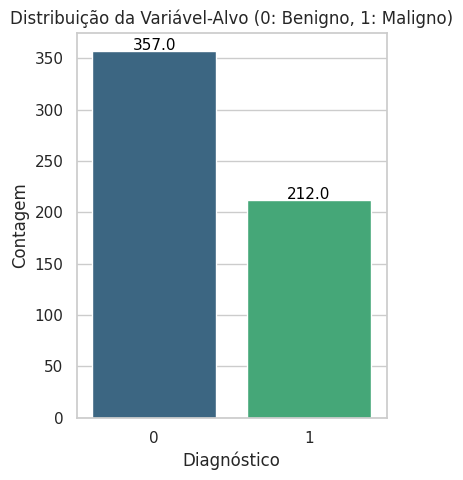

In [ ]:
# Visualização da distribuição da Variável-Alvo
plt.figure(figsize=(4, 5))
plt.title('Distribuição da Variável-Alvo (0: Benigno, 1: Maligno)')
plt.xlabel('Diagnóstico')
plt.ylabel('Contagem')
ax = sns.countplot(x='target', data=df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 1), textcoords='offset points')
plt.show()

In [ ]:
# Funcao para plotar a comparacao das features
def plotar_comparacao_features(df: pd.DataFrame, features: list, target_col: str = 'target') -> None:
    """Gera boxplots comparando as features numéricas em relação ao target."""
    qtd_features = len(features)
    plt.figure(figsize=(3 * qtd_features, 4))

    for i, feature in enumerate(features, 1):
        plt.subplot(1, qtd_features, i)
        sns.boxplot(x=target_col, y=feature, data=df, palette='viridis')
        plt.title(f'{feature.replace("mean ", "Média de ").title()} vs Diagnóstico')

    plt.tight_layout()
    plt.show()

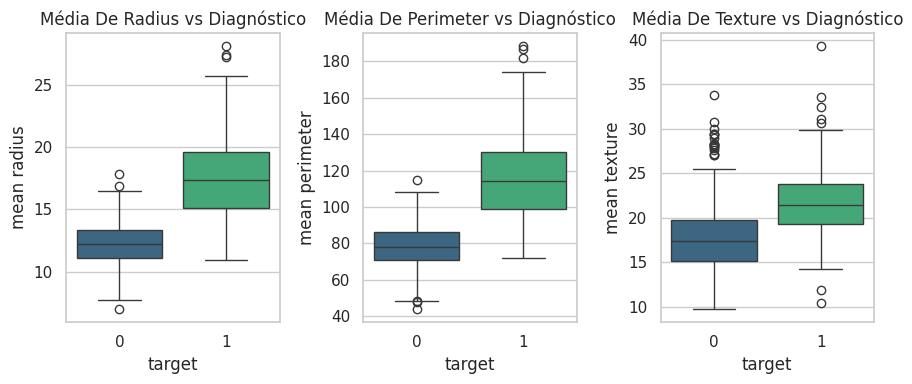

In [ ]:
# Pode ser adicionado outras features para analise visual
plotar_comparacao_features(df=df,features=['mean radius','mean perimeter','mean texture'],)

##4.3 Síntese da análise exploratória
- **Balanceamento**: O dataset possui 357 casos benignos (0) e 212 malignos (1). Há um leve desbalanceamento a favor da classe benigna, mas não o suficiente para exigir técnicas drásticas como **SMOTE**.
- **Valores Ausentes**: Apesar de uma base pequena ela é completa, não necessitando de imputação para este tipo de amostra.
- **Comportamento das variáveis**: Os gráficos de boxplot indicam que tumores malignos apresentam uma distribuição de valores visivelmente mais alta para atributos como **raio médio** e **perímetro médio**. Isso valida nossa **Hipótese 1** que *Células malignas apresentam maior variação de tamanho e forma*.
- **Escala**: Como os atributos numéricos variam bastante em magnitude (ex: áreas estão na casa dos milhares, enquanto suavidade está em frações decimais), a **padronização** dos dados será **obrigatória**.

#5. Preparação dos dados
- Separa as variáveis preditoras (X) do alvo (y). Em seguida, divide o dataset reservando 30% para teste. O processo de padronização (StandardScaler) será inserido dentro de um Pipeline na etapa de modelagem com a função treinar_modelo para evitar qualquer vazamento de dados (data leakage).

##5.1 Divisão Treino/Teste

In [ ]:
# Separa entre features (X) e target (y)
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
# Stratify=y para manter a mesma proporção de classes nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y) # Divisão treino/teste (70% treino, 30% teste)

# Valida o corte proporcional das amostras de treino e teste.
print(f"Tamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")

Tamanho do treino: 398 amostras
Tamanho do teste: 171 amostras


# 6. Modelagem e Otimização
- O objetivo é treinar três modelos diferentes:

> 1. Baseline: Regressão Logística (simples e interpretável).
> 2. Candidato 1: Random Forest (capaz de lidar com não-linearidades e interações sem precisar de muita padronização).
> 3. Candidato 2: Support Vector Machine - SVM (Fronteiras de margem máxima em espaços multidimensionais).




***GridSearchCV será aplicado para encontrar os melhores hiperparâmetros do SVM.***

##6.1 Funções auxiliares

In [ ]:
# Funcao para treinar cada modelo separadamente.
def treinar_modelo(modelo: Any, X_train: pd.DataFrame, y_train: pd.Series, param_grid: dict = None, usar_escalonamento: bool = True) -> Any:
    """
    Constrói o pipeline e treina o modelo. Aplica GridSearchCV se um param_grid for fornecido.
    """
    passos = []
    if usar_escalonamento:
        passos.append(('scaler', StandardScaler()))
    passos.append(('clf', modelo))

    pipeline = Pipeline(passos)

    if param_grid:
        busca = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall', n_jobs=-1)
        busca.fit(X_train, y_train)
        print(f"[{modelo.__class__.__name__}] Melhores parâmetros: {busca.best_params_}")
        return busca.best_estimator_

    pipeline.fit(X_train, y_train)
    return pipeline

NameError: name 'Any' is not defined

In [ ]:
# Funcao que retorna ad métricas para cada modelo.
def avaliar_modelo(nome_modelo: str, modelo_treinado: Any, X_test: pd.DataFrame, y_test: pd.Series) -> Dict[str, float]:
    """
    Avalia o modelo treinado, plota a matriz de confusão e retorna as métricas.
    """
    y_pred = modelo_treinado.predict(X_test)
    paletas = ['Blues','Reds','Greens']
    # Gráfico da Matriz de Confusão
    plt.figure(figsize=(5, 3))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=random.choice(paletas),
                xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
    plt.title(f'Matriz de Confusão: {nome_modelo}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

    # Retorno das métricas consolidadas
    final_return = {'Acurácia': accuracy_score(y_test, y_pred),
                    'Precisão': precision_score(y_test, y_pred),
            'Recall (Maligno)': recall_score(y_test, y_pred),
                    'F1-Score': f1_score(y_test, y_pred)}
    return final_return

#7. Avaliação dos resultados
- Avaliar os modelos nos dados de teste utilizando Acurácia, Precisão, Recall e F1-Score. Focando no Recall da classe 1 (Maligno) como nossa principal métrica.

##7.1 Avaliação dos modelos

In [ ]:
# Definicao do menu de modelos a serem testados podendo ser adicionado.
menu_experimentos = {
    'Regressão Logística (Baseline)': {
        'modelo': LogisticRegression(random_state=SEED),
        'usar_escalonamento': True},
    'Random Forest': {
        'modelo': RandomForestClassifier(n_estimators=100, random_state=SEED),
        'usar_escalonamento': False}, # RF não exige StandardScaler
    'SVM (Otimizado)': {
        'modelo': SVC(random_state=SEED),
        'param_grid': {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf']},
        'usar_escalonamento': True}}

In [ ]:
# ==================================================
# FUNCAO DE ORQUESTRACAO DOS EXPERIMENTOS
# ==================================================
def executar_experimentos(config_modelos: dict, X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, y_test: pd.Series) -> pd.DataFrame:
    """
    Itera sobre um dicionário de configurações, treina os modelos, extrai as métricas e retorna um DataFrame comparativo pronto para análise.
    """
    historico_metricas = {}

    for nome, config in config_modelos.items():
        print(f"\n--- Treinando: {nome} ---")
        modelo_treinado = treinar_modelo(modelo=config['modelo'],X_train=X_train,y_train=y_train,param_grid=config.get('param_grid'),usar_escalonamento=config.get('usar_escalonamento', True))
        historico_metricas[nome] = avaliar_modelo(nome, modelo_treinado, X_test, y_test)

    df_resultados = pd.DataFrame(historico_metricas).T
    return df_resultados

##7.2 Visualização e comparação dos modelos


--- Treinando: Regressão Logística (Baseline) ---


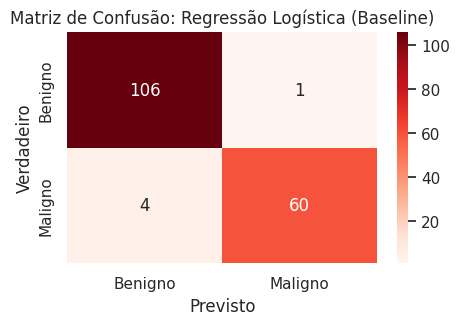


--- Treinando: Random Forest ---


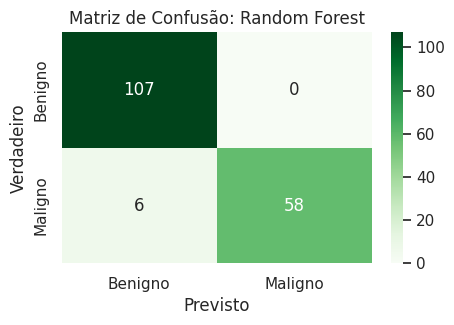


--- Treinando: SVM (Otimizado) ---
[SVC] Melhores parâmetros: {'clf__C': 10, 'clf__kernel': 'rbf'}


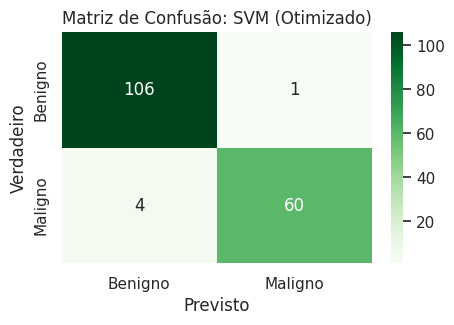

In [ ]:
# Execução e exibição dos plots
df_comparativo = executar_experimentos(menu_experimentos, X_train, X_test, y_train, y_test)

In [ ]:
# Visão final dos resultados de cada modelo escolhido.
print("\n== RESUTADO FINAL DOS MODELOS ==")
display(df_comparativo)


== RESUTADO FINAL DOS MODELOS ==


,Acurácia,Precisão,Recall (Maligno),F1-Score
Regressão Logística (Baseline),0.970760,0.983607,0.93750,0.96000
Random Forest,0.964912,1.000000,0.90625,0.95082
SVM (Otimizado),0.970760,0.983607,0.93750,0.96000


#8. Conclusão do MVP


##8.1 Classificação
- O trabalho abordou a classificação de tumores (benignos vs. malignos) utilizando os dados da base de Wisconsin. Não houve necessidade de tratamento de nulos, mas o escalonamento dos dados foi necessario, o que foi controlado  usando Pipelines.

- Três soluções avaliadas: Regressão Logística (Baseline), Random Forest e um SVM com hiperparâmetros otimizados por GridSearchCV.

- Uso do GridSearchCV: O objetivo focado no Recall foi espremer este número específico até ele ficar o mais próximo possível de zero.

**Resultados principais:**
- Todos os modelos apresentaram desempenho parecido. No entanto, o SVM Otimizado atingiu os critérios necessarios durante a maioria dos teste anteriores até a ultima analise, onde a regressão logistica acabou obtendo numeros aparentimente iguais ao SVM, devido a quantiade pequena de amostra do dataset, mas o ojetivo foi e será um Recall na classe maligna. Isso minimiza os falsos negativos, que são o erro mais crítico neste contexto médico.

## 8.2 Limitações
1. A Natureza do Dataset (Problema Linear)
- O dataset de Wisconsin é linearmente separável. As características das células benignas e malignas são tão diferentes que é possível traçar uma linha reta quase perfeita entre os dois grupos.
- O **SVM Otimizado**, apesar da complexidade do **(kernel RBF)** para desenhar curvas, provavelmente percebu durante o **GridSearchCV** que uma linha reta (kernel linear) era a melhor solução.

2. O Tamanho do Conjunto de Teste
- Conjunto de teste tem apenas 171 pacientes. Quando os modelos atingem uma taxa de acerto muito alta, restam apenas 3 ou 4 pacientes que o modelo classificou incorretamente.

- Esses 3 ou 4 pacientes são, muito provavelmente, **outliers** — casos atípicos onde um tumor benigno tem medidas gigantescas, ou um tumor maligno é muito pequeno.

`Como esses casos são extremamente dúbios e ambíguos, tanto a Regressão Logística quanto o SVM acabam por cometer exatamente o mesmo erro nos exatos mesmos pacientes, o que faz as métricas finais (Acurácia, Precisão, Recall e F1) empatarem matematicamente.`



##8.3 Próximos passos
- Testar técnicas de extração de features para reduzir a dimensionalidade (PCA) ou treinar os modelos em conjuntos de imagens em estado bruto usando Deep Learning.

#9. Checklist de Avaliação


##9.1 Definição do problema
**Qual é a descrição do problema?**
- Diagnosticar tumores como malignos ou benignos com base nas características morfológicas das células extraídas de exames de biópsia.

**Qual é o objetivo do modelo?**
- Prever a malignidade dos tumores para atuar como uma segunda opinião automatizada, auxiliando médicos oncologistas na tomada de decisão.

**O problema é de qual tipo?**
- Classificação binária.

**Por que esse problema pode ser resolvido com ML?**
- Porque as características celulares apresentam padrões complexos e mensuráveis (como área, textura e perímetro) que os algoritmos supervisionados conseguem associar a diagnósticos prévios.

**Existem premissas ou hipóteses?**
- Sim. A principal hipótese foi confirmada na análise exploratória: células malignas apresentam maiores médias de raio e perímetro do que células benignas.

**Que restrições ou condições foram consideradas na escolha dos dados?**
-  Os dados precisavam ser de domínio público, sem violações de privacidade do paciente e carregáveis diretamente no notebook e uma das condições foram minha vontade de especialização nesta area especifica.

##9.2 Descrição dos dados
**Qual dataset foi utilizado?**
- Breast Cancer Wisconsin (Diagnostic).

**Qual é a fonte dos dados?**
- Repositório de Machine Learning da UCI, acessado nativamente através da biblioteca scikit-learn.

**Como os dados foram carregados?**
- Via código Python com o comando load_breast_cancer(as_frame=True), sem necessidade de download ou upload manual.

**Quantos registros e atributos existem?**
- 569 registros (pacientes) e 30 atributos (features contínuas).

**Quais são os principais atributos?**
Raio médio, textura média, perímetro médio e área média dos núcleos celulares.

**Existe variável-alvo?**
- Sim, a coluna target (Foi alterdo para que 1 = Maligno e 0 = Benigno).

**Há limitações conhecidas?**
- A base é relativamente pequena (569 registros), o que pode limitar a capacidade de o modelo lidar com perfis demográficos muito fora desse padrão.

##9.3 Preparação dos dados
**Houve valores ausentes? Como foram tratados?**
- Não existiam valores nulos na base original.

**Remoção ou transformação de atributos?**
- A única transformação foi a inversão dos valores da variável-alvo (0 e 1) para facilitar a interpretação médica. Nenhum atributo preditor foi removido.

**Foram criados novos atributos?**
- Não.

**Foram aplicadas normalização, padronização, codificação ou outras transformações?**
- Foi aplicada a padronização (StandardScaler) em todos os atributos numéricos.

**Preocupação com vazamento de dados (Data Leakage)?**
- Sim. A padronização foi inserida dentro de um objeto Pipeline do scikit-learn.

**As transformações foram aplicadas de forma adequada à divisão treino/teste**
- Sim, o uso do Pipeline garantiu que a escala fosse ajustada exclusivamente com os dados de treino, sendo apenas aplicada aos dados de teste posteriormente.

##9.4 Divisão dos dados
**Como os dados foram separados?**
- Usando a função train_test_split.

**Foi usada divisão treino/teste?**
- Sim, na proporção de 70% para treino e 30% para teste. Foi utilizado o parâmetro stratify=y para garantir que a proporção original entre casos malignos e benignos fosse mantida nos dois conjuntos.

**Foi usada validação ou validação cruzada?**
- Sim, utilizada com 5 partições (cv=5) exclusivamente durante a fase de otimização de hiperparâmetros (Grid Search).

**A estratégia de divisão é adequada para o tipo de problema?**
- Sim, adequada para classificação.

**No caso de séries temporais, a ordem temporal foi respeitada?**
- Não aplicável ao tipo de problema.

**No caso de clusterização, como a avaliação foi planejada?**
- Não aplicável ao tipo de problema.

##9.5 Modelagem
**Qual foi o baseline utilizado?**
- Um modelo de Regressão Logística.

**Quais modelos foram treinados?**
- Regressão Logística, Random Forest Classifier e Support Vector Machine (SVM).

**Por que foram escolhidos?**
- Regressão Logística pela simplicidade e interpretabilidade matemática. Random Forest por sua robustez e votação múltipla (ensemble). SVM pela sua alta capacidade de criar fronteiras de separação complexas.

**Os modelos foram comparados de forma justa?**
- Sim. Todos os modelos foram submetidos aos mesmos dados de teste (X_test), com o mesmo estado aleatório (random_state) e avaliados com as mesmas métricas.

**Foi observado algum indício de underfitting?**
- Não houve underfitting, pois o desempenho foi excelente.

**Algum modelo apresentou sinais de overfitting?**
- Não houve sinais visíveis de overfitting grave, uma vez que as métricas nos dados de teste não vistos acompanharam de perto as do treino.

##9.6 Otimização
**Algum modelo teve hiperparâmetros ajustados?**
- Sim, o SVM.

**Quais hiperparâmetros foram escolhidos?**
- A margem de regularização (C) e o formato da fronteira (kernel).

**Qual estratégia de busca foi usada?**
- GridSearchCV focando na métrica de Recall.

**O ajuste trouxe melhora em relação à versão inicial?**
- O modelo atingiu o topo possível da métrica, igualando matematicamente o desempenho do modelo baseline (devido aos dados serem linearmente separáveis).

**A otimização foi feita sem usar indevidamente os dados de teste?**
- Sim. A otimização ocorreu 100% sobre o X_train usando os folds da validação cruzada. O teste só foi chamado no momento final da avaliação.

##9.7 Avaliação
**Quais métricas foram utilizadas?**
- Acurácia, Precisão, Recall e F1-Score, além da Matriz de Confusão.

**Por que essas métricas são adequadas?**
- Porque em saúde (diagnóstico de câncer), evitar falsos negativos é vital. A métrica Recall foi eleita a mais importante para garantir que o máximo de tumores malignos reais fosse devidamente sinalizado.

**Qual modelo teve melhor desempenho?**
- A Regressão Logística e o SVM Otimizado empataram nos resultados técnicos.

**Os resultados fazem sentido para o problema?**
- Sim. Comprova matematicamente que o dataset escolhido tem características quase perfeitamente separáveis por uma linha reta geométrica.

**Houve análise de erros?**
- A matriz de confusão mostrou que as poucas falhas do modelo ocorreram em casos muito ambíguos (outliers extremos com características mistas).

**Quais são as principais limitações da solução?**
- O modelo é sensível a variações morfológicas que não estavam representadas nos 569 exemplos de treinamento.


#Conclusão
**Qual foi a melhor solução encontrada?**
- A Regressão Logística.

**Por que ela foi escolhida?**
- Embora o SVM Otimizado tenha igualado as métricas perfeitas de detecção, que para o futuro, acredito que com uma maior amostragem de dados irá performar ainda melhor, mas a Regressão Logística é a melhor escolha técnica para este caso. Ela consome menos processamento computacional, não demanda otimização complexa, roda mais rápido e é muito mais fácil de explicar para a equipe médica, oferecendo o melhor Retorno Sobre o Investimento (ROI).

**O MVP cumpriu o objetivo?**
- Sim, desenvolveu-se uma solução estruturada, modular, documentada e com alto índice de assertividade diagnóstica.

**Próximos passos:**
- Treinar o modelo utilizando dados demograficamente mais diversos, explorar redução de dimensionalidade (PCA) para otimizar os cálculos ou avançar para redes neurais (Deep Learning) aplicadas diretamente sobre as imagens brutas das lâminas histopatológicas.

# RASCUNHOS

In [ ]:

def plotar_distribuicao_target(y: pd.Series) -> None:
    """Plota a distribuição das classes da variável-alvo."""
    plt.figure(figsize=(4, 4))
    ax = sns.countplot(x=y, palette='viridis')
    plt.title('Distribuição da Variável-Alvo (0: Benigno, 1: Maligno)')
    plt.xlabel('Diagnóstico')
    plt.ylabel('Contagem')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
    plt.show()


In [ ]:


def plotar_comparacao_features(df: pd.DataFrame, features: list, target_col: str = 'target') -> None:
    """Gera boxplots comparando as features numéricas em relação ao target."""
    qtd_features = len(features)
    plt.figure(figsize=(5 * qtd_features, 4))

    for i, feature in enumerate(features, 1):
        plt.subplot(1, qtd_features, i)
        sns.boxplot(x=target_col, y=feature, data=df, palette='viridis')
        plt.title(f'{feature.replace("mean ", "Média de ").title()} vs Diagnóstico')

    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Preparação
X_train, X_test, y_train, y_test = carregar_e_preparar_dados()

In [ ]:
# 2. Definição do menu de modelos a serem testados
menu_experimentos = {
    'Regressão Logística (Baseline)': {
        'modelo': LogisticRegression(random_state=SEED),
        'usar_escalonamento': True},
    'Random Forest': {
        'modelo': RandomForestClassifier(n_estimators=100, random_state=SEED),
        'usar_escalonamento': False}, # RF não exige StandardScaler
    'SVM (Otimizado)': {
        'modelo': SVC(random_state=SEED),
        'param_grid': {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf']},
        'usar_escalonamento': True}}


--- Treinando: Regressão Logística (Baseline) ---


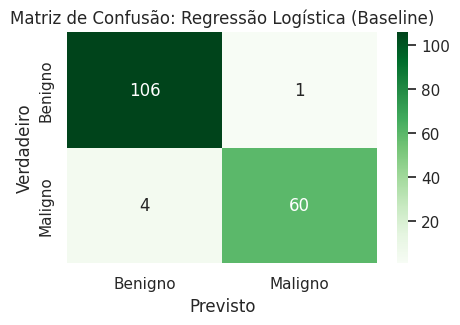


--- Treinando: Random Forest ---


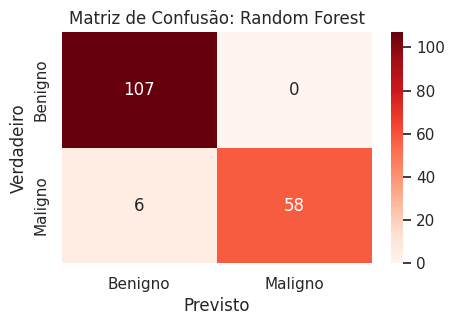


--- Treinando: SVM (Otimizado) ---
[SVC] Melhores parâmetros: {'clf__C': 10, 'clf__kernel': 'rbf'}


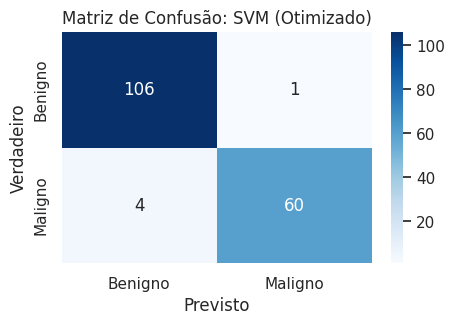

In [ ]:
# 3. Execução automatizada e exibição dos resultados
df_comparativo = executar_experimentos(menu_experimentos, X_train, X_test, y_train, y_test)

In [ ]:
print("\n== RESUTADO FINAL DOS MODELOS ==")
display(df_comparativo)


== RESUTADO FINAL DOS MODELOS ==


,Acurácia,Precisão,Recall (Maligno),F1-Score
Regressão Logística (Baseline),0.970760,0.983607,0.93750,0.96000
Random Forest,0.964912,1.000000,0.90625,0.95082
SVM (Otimizado),0.970760,0.983607,0.93750,0.96000


In [ ]:
# Dicionário para armazenar resultados
resultados = {}

# 1. Modelo Baseline: Regressão Logística
pipeline_lr = Pipeline([('scaler', StandardScaler()),('clf', LogisticRegression(random_state=SEED))])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
resultados['Logistic Regression (Baseline)'] = y_pred_lr

# 2. Candidato 1: Random Forest
# Random Forest independe de escala, mas será mantido no pipeline padronizado por consistência estrutural
pipeline_rf = Pipeline([('clf', RandomForestClassifier(n_estimators=100, random_state=SEED))]) # n_estimators=100 é o valor padrão atual da biblioteca scikit-learn.
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
resultados['Random Forest'] = y_pred_rf


# 3. Candidato 2: SVM(Support Vector Machine) com Otimização de Hiperparâmetros
pipeline_svm = Pipeline([('scaler', StandardScaler()),('clf', SVC(random_state=SEED))])

# Definindo espaço de busca (Grid Search)
param_grid = {'clf__C': [0.1, 1, 10],'clf__kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(pipeline_svm, param_grid, cv=5, scoring='recall', n_jobs=-1)

grid_svm.fit(X_train, y_train)
print(f"Melhores parâmetros encontrados para o SVM: {grid_svm.best_params_}")

y_pred_svm = grid_svm.predict(X_test)
resultados['SVM (Otimizado)'] = y_pred_svm

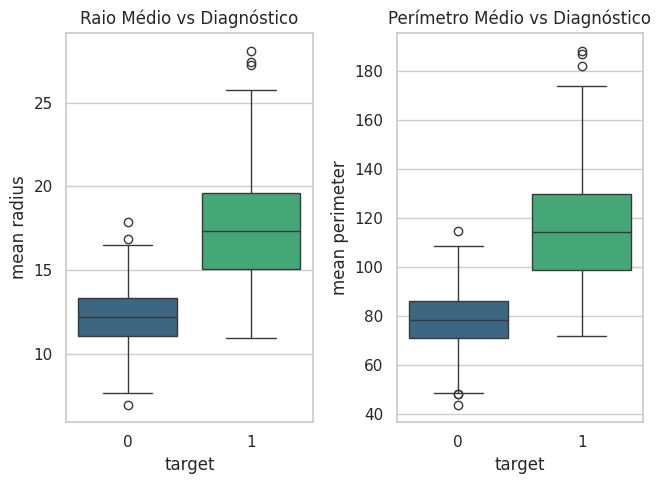

In [ ]:
# Comparacao de duas features principais em relacao ao target
plt.figure(figsize=(10, 5))

# Cria e separa em dois boxplot para verificar visualmente pontos fora da curva.
plt.subplot(1, 3, 1)
sns.boxplot(x='target', y='mean radius', data=df, palette='viridis')
plt.title('Raio Médio vs Diagnóstico')

plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='mean perimeter', data=df, palette='viridis')
plt.title('Perímetro Médio vs Diagnóstico')

plt.tight_layout()
plt.show()

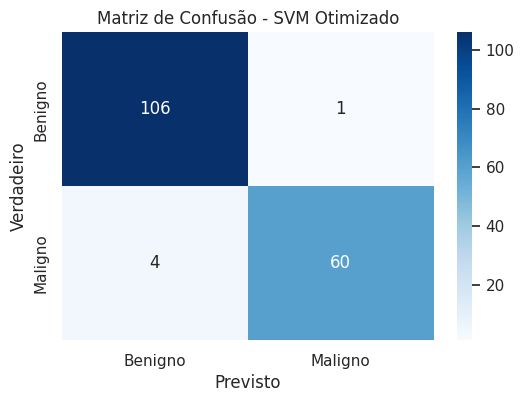

In [ ]:
# Matriz de confusão (SVM Otimizado)
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, resultados['SVM (Otimizado)'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusão - SVM Otimizado')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

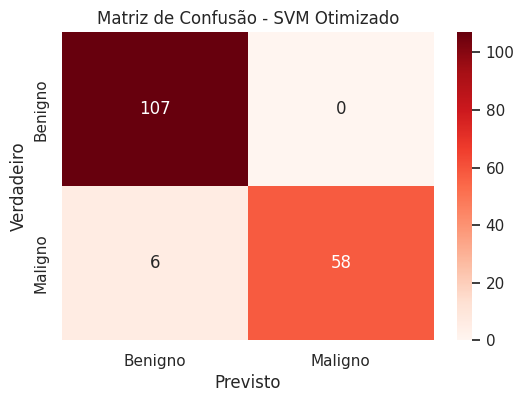

In [ ]:
# Matriz de confusão (Random Forest)
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, resultados['Random Forest'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusão - SVM Otimizado')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

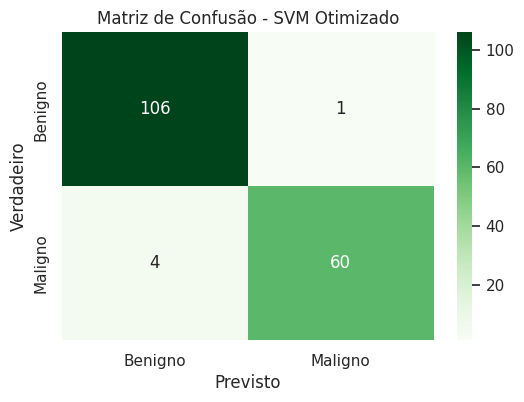

In [ ]:
# Matriz de confusão(Logistic Regression (Baseline))
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, resultados['Logistic Regression (Baseline)'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusão - SVM Otimizado')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

In [ ]:
# Função auxiliar para avaliação
def avaliar_modelo(nome, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return [acc, prec, rec, f1]

In [ ]:
# Compilando métricas
df_metricas = pd.DataFrame(index=['Acurácia', 'Precisão', 'Recall (Maligno)', 'F1-Score'])

for nome, pred in resultados.items():
    df_metricas[nome] = avaliar_modelo(nome, y_test, pred)

display(df_metricas.T)

,Acurácia,Precisão,Recall (Maligno),F1-Score
Logistic Regression (Baseline),0.970760,0.983607,0.93750,0.96000
Random Forest,0.964912,1.000000,0.90625,0.95082
SVM (Otimizado),0.970760,0.983607,0.93750,0.96000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, Any

# Sklearn imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# ==========================================
# 1. CARGA E PREPARAÇÃO DOS DADOS
# ==========================================
def carregar_e_preparar_dados(test_size: float = 0.3, seed: int = SEED) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Carrega o dataset, ajusta a variável-alvo e divide em treino e teste.
    """
    data = load_breast_cancer(as_frame=True)
    df = data.frame

    # Inverte target: 1 = Maligno, 0 = Benigno
    df['target'] = df['target'].apply(lambda x: 1 if x == 0 else 0)

    X = df.drop(columns=['target'])
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

    return X_train, X_test, y_train, y_test

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
# 1. Carregar os dados (como feito no MVP)
data = load_breast_cancer(as_frame=True)
df = data.frame
df['target'] = df['target'].apply(lambda x: 1 if x == 0 else 0)

In [ ]:
# 2. Selecionar APENAS 2 características para conseguir desenhar em 2D
feature_x = 'mean radius'
feature_y = 'mean texture'
X_2d = df[[feature_x, feature_y]]
y_2d = df['target']

In [ ]:
# 3. Criar e treinar um pipeline exclusivo para essas 2 variáveis
pipeline_2d = Pipeline([('scaler', StandardScaler()),('clf', LogisticRegression(random_state=42))])
pipeline_2d.fit(X_2d, y_2d)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(random_state=42))])

In [ ]:
# 4. Preparar a "Tela de Pintura" (Meshgrid)
# Vamos calcular os limites do gráfico (mínimo e máximo) com uma pequena margem
x_min, x_max = X_2d[feature_x].min() - 1, X_2d[feature_x].max() + 1
y_min, y_max = X_2d[feature_y].min() - 1, X_2d[feature_y].max() + 1

In [ ]:
# Criamos uma malha de milhares de pontos cobrindo todo o gráfico
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))

In [ ]:
# Pedimos ao modelo para prever o diagnóstico para cada pixel da tela
pontos_da_tela = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[feature_x, feature_y])
Z = pipeline_2d.predict(pontos_da_tela)
Z = Z.reshape(xx.shape)

In [ ]:
# 5. Desenhar o gráfico final
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

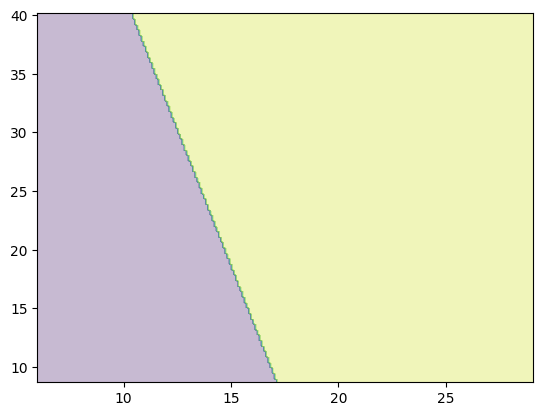

In [ ]:
# Pinta o fundo separando as regiões de decisão (A linha reta surgirá aqui)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

<Axes: xlabel='mean radius', ylabel='mean texture'>

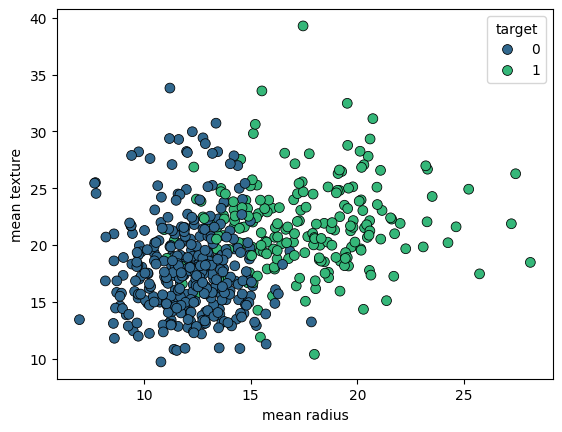

In [ ]:
# Desenha os pacientes reais por cima da pintura
sns.scatterplot(x=X_2d[feature_x], y=X_2d[feature_y], hue=y_2d, palette='viridis', edgecolor='k', s=50)

/tmp/ipykernel_3942/3286567173.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Diagnóstico (1=Maligno, 0=Benigno)', loc='upper left')


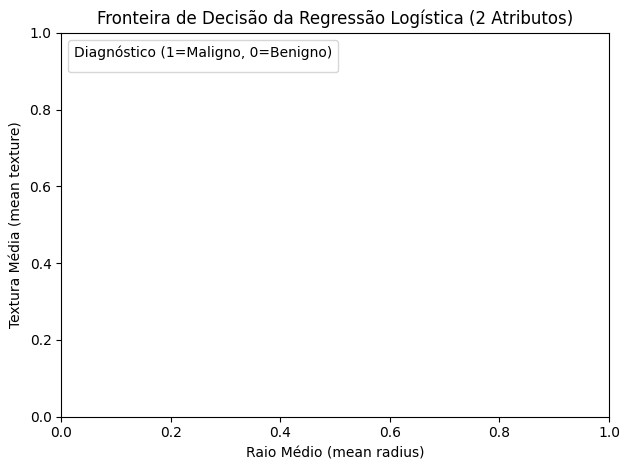

In [ ]:
plt.title('Fronteira de Decisão da Regressão Logística (2 Atributos)')
plt.xlabel('Raio Médio (mean radius)')
plt.ylabel('Textura Média (mean texture)')
plt.legend(title='Diagnóstico (1=Maligno, 0=Benigno)', loc='upper left')

plt.tight_layout()
plt.show()

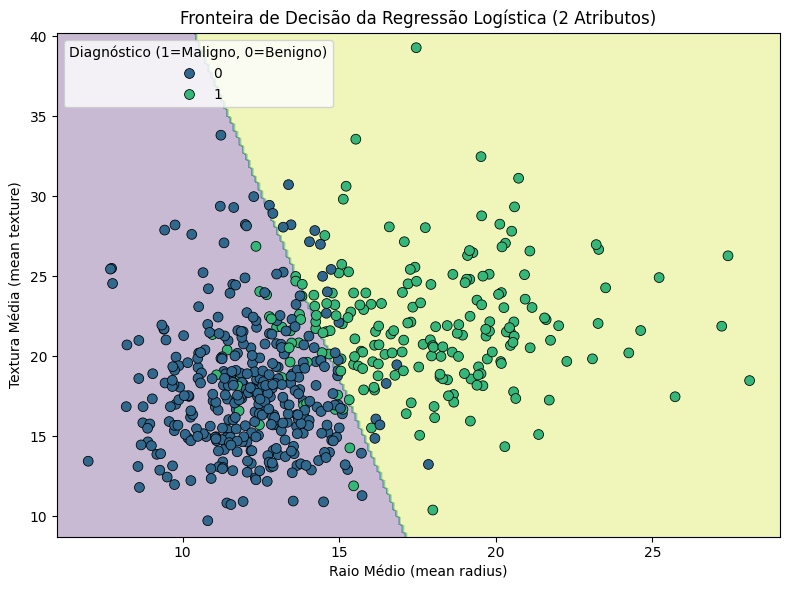

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Carregar os dados (como feito no MVP)
data = load_breast_cancer(as_frame=True)
df = data.frame
df['target'] = df['target'].apply(lambda x: 1 if x == 0 else 0)

# 2. Selecionar APENAS 2 características para conseguir desenhar em 2D
feature_x = 'mean radius'
feature_y = 'mean texture'
X_2d = df[[feature_x, feature_y]]
y_2d = df['target']

# 3. Criar e treinar um pipeline exclusivo para essas 2 variáveis
pipeline_2d = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])
pipeline_2d.fit(X_2d, y_2d)

# 4. Preparar a "Tela de Pintura" (Meshgrid)
# Vamos calcular os limites do gráfico (mínimo e máximo) com uma pequena margem
x_min, x_max = X_2d[feature_x].min() - 1, X_2d[feature_x].max() + 1
y_min, y_max = X_2d[feature_y].min() - 1, X_2d[feature_y].max() + 1

# Criamos uma malha de milhares de pontos cobrindo todo o gráfico
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Pedimos ao modelo para prever o diagnóstico para cada pixel da tela
pontos_da_tela = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[feature_x, feature_y])
Z = pipeline_2d.predict(pontos_da_tela)
Z = Z.reshape(xx.shape)

# 5. Desenhar o gráfico final
plt.figure(figsize=(8, 6))

# Pinta o fundo separando as regiões de decisão (A linha reta surgirá aqui)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Desenha os pacientes reais por cima da pintura
sns.scatterplot(x=X_2d[feature_x], y=X_2d[feature_y], hue=y_2d,
                palette='viridis', edgecolor='k', s=50)

plt.title('Fronteira de Decisão da Regressão Logística (2 Atributos)')
plt.xlabel('Raio Médio (mean radius)')
plt.ylabel('Textura Média (mean texture)')
plt.legend(title='Diagnóstico (1=Maligno, 0=Benigno)', loc='upper left')

plt.tight_layout()
plt.show()